In [1]:
import numpy as np
import matplotlib.pyplot as plt
from episbi.models import Transition, compartment_model

In [2]:
compartments = ["S", "E", "I", "R"]
transitions = [
    Transition("S", "E", "beta * S * I / N", name="S_to_E"),
    Transition("E", "I", "kappa * E", name="E_to_I"),
    Transition("I", "R", "gamma * I", name="I_to_R"),
]
param_names = ["beta", "kappa", "gamma"]

In [3]:
N = 100_000
E0 = 0
I0 = 10
R0 = 0
S0 = N - E0 - I0 - R0

total_days = 100
initial_conditions = {"S": S0, "E": E0, "I": I0, "R": R0}
theta = {"beta": 0.80, "kappa": 0.30, "gamma": 0.35}
n_simulations = 100

In [4]:
sto_seir_model = compartment_model(
    compartments=compartments,
    transitions=transitions,
    param_names=param_names,
    model_type="stochastic",
    initial_conditions=initial_conditions,
    observed={"compartments": ["S","E","I","R"]}
)

In [5]:
print(sto_seir_model.show())

Model type: stochastic
Compartments: S, E, I, R
Parameters: beta, kappa, gamma
Transitions:
  S_to_E: S -> E, rate=beta * S * I / N
  E_to_I: E -> I, rate=kappa * E
  I_to_R: I -> R, rate=gamma * I
Observed:
  S
  E
  I
  R


In [6]:
sto_results = [sto_seir_model(theta, total_days=total_days, dt=0.01) for seed in range(n_simulations)]

In [7]:
def stack_results(results, name):
    return np.stack([result[name] for result in results], axis=0)

sto_arrays = {name: stack_results(sto_results, name) for name in sto_results[0].keys()}

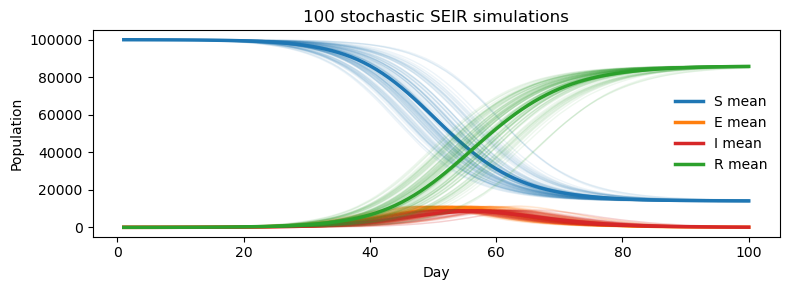

In [8]:
days = np.arange(1, sto_arrays["S"].shape[1] + 1)
fig, ax = plt.subplots(1, 1, figsize=(8, 3), sharex=True)
colors = {"S": "tab:blue", "E": "tab:orange", "I": "tab:red", "R": "tab:green"}

for name in ["S", "E", "I", "R"]:
    values = sto_arrays[name]
    for trajectory in values:
        ax.plot(days, trajectory, color=colors[name], alpha=0.08, linewidth=1)
    ax.plot(days, values.mean(axis=0), color=colors[name], linewidth=2.5, label=f"{name} mean")

ax.set_xlabel("Day")
ax.set_ylabel("Population")
ax.set_title("100 stochastic SEIR simulations")
ax.legend(frameon=False)
fig.tight_layout()
plt.show()